In [1]:
import pandas as pd
import numpy as np

sales = pd.read_csv("sales_cleaned.csv")
inventory = pd.read_csv("inventory_cleaned.csv")

sales.head()

,order_id,product_id,date,quantity,price
0,1001,P101,2026-03-01,2,499.99
1,1002,P102,2026-03-01,1,899.50
2,1003,P103,2026-03-02,3,299.99
3,1004,P101,2026-03-02,1,499.99
4,1005,P104,2026-03-03,5,149.99


In [2]:
df = pd.merge(sales, inventory, on="product_id")

df.head()

,order_id,product_id,date,quantity,price,stock_level,last_updated
0,1001,P101,2026-03-01,2,499.99,50,2026-03-01
1,1002,P102,2026-03-01,1,899.50,30,2026-03-01
2,1003,P103,2026-03-02,3,299.99,40,2026-03-02
3,1004,P101,2026-03-02,1,499.99,50,2026-03-01
4,1005,P104,2026-03-03,5,149.99,100,2026-03-02


In [3]:
df["date"] = pd.to_datetime(df["date"])

df["day_of_week"] = df["date"].dt.day_name()
df["month"] = df["date"].dt.month

In [5]:
def time_pricing(row):

    price = row["price"]

    if row["day_of_week"] in ["Saturday","Sunday"]:
        price = price * 1.10

    return price

In [6]:
df["adjusted_price"] = df.apply(time_pricing, axis=1)

In [7]:
def inventory_pricing(row):

    price = row["adjusted_price"]

    if row["inventory"] < 20:
        price = price * 1.15

    elif row["inventory"] > 100:
        price = price * 0.90

    return price

In [11]:
df.columns

Index(['order_id', 'product_id', 'date', 'quantity', 'price', 'stock_level',
       'last_updated', 'day_of_week', 'month', 'adjusted_price'],
      dtype='object')

In [12]:
def inventory_pricing(row):

    price = row["adjusted_price"]

    if row["stock_level"] < 20:
        price = price * 1.15

    elif row["stock_level"] > 100:
        price = price * 0.90

    return price

In [13]:
df["adjusted_price"] = df.apply(inventory_pricing, axis=1)

In [14]:
df["original_revenue"] = df["price"] * df["quantity"]

In [15]:
df["new_revenue"] = df["adjusted_price"] * df["quantity"]

In [16]:
original_revenue = df["original_revenue"].sum()
new_revenue = df["new_revenue"].sum()

print("Original Revenue:", original_revenue)
print("New Revenue:", new_revenue)

Original Revenue: 8268.29
New Revenue: 8426.242


In [17]:
revenue_lift = ((new_revenue - original_revenue) / original_revenue) * 100

print("Revenue Lift (%):", revenue_lift)

Revenue Lift (%): 1.910334543176392


In [18]:
df[["price","adjusted_price","quantity","original_revenue","new_revenue"]].head()

,price,adjusted_price,quantity,original_revenue,new_revenue
0,499.99,549.989,2,999.98,1099.978
1,899.50,989.450,1,899.50,989.450
2,299.99,299.990,3,899.97,899.970
3,499.99,499.990,1,499.99,499.990
4,149.99,149.990,5,749.95,749.950


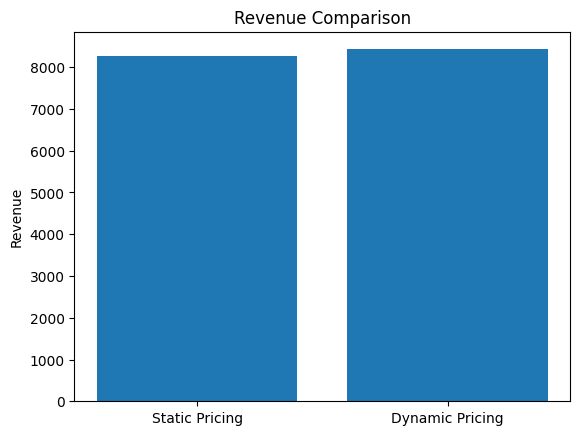

In [19]:
import matplotlib.pyplot as plt

plt.bar(["Static Pricing","Dynamic Pricing"], [original_revenue,new_revenue])
plt.title("Revenue Comparison")
plt.ylabel("Revenue")
plt.show()

In [20]:
df.to_csv("pricing_results.csv", index=False)